# Double Responses in Decision Tasks
Group 17

In [1]:
import numpy as np
import bayesflow as bf
import keras

SEED = 2026
N_TRIALS = 1000
MAX_T = 3.0
DT = 0.02
DR_WINDOW = 0.25  # 250ms double-response window, from Evans et al. (2020)

PRIORS = {
    "nu": {"shape": 5, "scale": 0.5},
    "alpha1": {"shape": 5, "scale": 0.2},
    "tau": {"scale": 0.15},
}

rng = np.random.default_rng(SEED)

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Priors

In [2]:
def prior():
    nu = rng.gamma(shape=PRIORS["nu"]["shape"], scale=PRIORS["nu"]["scale"], size=2)
    alpha1 = rng.gamma(shape=PRIORS["alpha1"]["shape"], scale=PRIORS["alpha1"]["scale"])
    tau = rng.exponential(scale=PRIORS["tau"]["scale"])
    return {"nu": nu, "alpha1": alpha1, "tau": tau}

print(prior())

{'nu': array([1.57722685, 0.8259513 ]), 'alpha1': 1.2371612415922888, 'tau': 0.1927229427713679}


## 2. Simulator

In [3]:
def context():
    return {"n": N_TRIALS}

def simulate_dataset(nu, alpha1, tau, n=N_TRIALS, max_t=MAX_T, dt=DT, dr_window=DR_WINDOW):
    total_t = max_t + dr_window
    n_steps = int(total_t / dt)
    sqrt_dt = np.sqrt(dt)

    evidence0 = np.zeros(n)
    evidence1 = np.zeros(n)
    crossed0 = np.zeros(n, dtype=bool)
    crossed1 = np.zeros(n, dtype=bool)
    cross_time0 = np.full(n, np.inf)
    cross_time1 = np.full(n, np.inf)

    for step in range(1, n_steps + 1):
        t = step * dt
        evidence0 += nu[0] * dt + rng.normal(scale=sqrt_dt, size=n)
        evidence1 += nu[1] * dt + rng.normal(scale=sqrt_dt, size=n)

        newly0 = (~crossed0) & (evidence0 >= alpha1)
        newly1 = (~crossed1) & (evidence1 >= alpha1)
        cross_time0[newly0] = t
        cross_time1[newly1] = t
        crossed0 |= newly0
        crossed1 |= newly1

        if crossed0.all() and crossed1.all():
            break

    win_time = np.minimum(cross_time0, cross_time1)
    lose_time = np.maximum(cross_time0, cross_time1)
    win_time = np.where(np.isinf(win_time), max_t, win_time)

    correct = np.where(cross_time0 < cross_time1, 0.0, 1.0)
    first_response_time = win_time + tau

    gap = lose_time - win_time
    double_flag = ((gap <= dr_window) & (~np.isinf(lose_time))).astype(float)
    second_response_time = np.where(double_flag == 1.0, gap, 0.0)

    return {
        "first_response_time": first_response_time,
        "correct": correct,
        "double_flag": double_flag,
        "second_response_time": second_response_time,
    }

p = prior()
data = simulate_dataset(p["nu"], p["alpha1"], p["tau"])
print("double response rate:", data["double_flag"].mean())

double response rate: 0.522


## 3. BayesFlow Simulator + Adapter

In [4]:
simulator = bf.make_simulator([context, prior, simulate_dataset])

adapter = (
    bf.Adapter()
    .as_set(["first_response_time", "correct", "double_flag", "second_response_time"])
    .constrain(["nu", "alpha1", "tau"], lower=0)
    .standardize(include="nu", mean=2.502, std=1.105)
    .standardize(include="alpha1", mean=1.005, std=0.449)
    .standardize(include="tau", mean=0.159, std=0.165)
    .concatenate(["nu", "alpha1", "tau"], into="inference_variables")
    .concatenate(["first_response_time", "correct", "double_flag", "second_response_time"], into="summary_variables")
)

batch = simulator.sample(5)
adapted = adapter(batch)
for k, v in adapted.items():
    print(k, v.shape)

n (5, 1)
inference_variables (5, 4)
summary_variables (5, 1000, 4)


## 4. Workflow + Training
Training from scratch here takes ~2 hours. To skip straight to using an already-trained model, go to section 5 instead.

In [5]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=bf.networks.CouplingFlow(),
    summary_network=bf.networks.DeepSet(),
    inference_variables=["nu", "alpha1", "tau"],
    inference_conditions=["n"],
    summary_variables=["first_response_time", "correct", "double_flag", "second_response_time"],
)
history = workflow.fit_online(epochs=100, num_batches_per_epoch=50, batch_size=32)
workflow.approximator.save("../../results/trained_model_v2.keras")

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 397ms/step - loss: 5.2048
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 403ms/step - loss: 4.4189
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - loss: 3.6806
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 400ms/step - loss: 3.0710
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 402ms/step - loss: 2.4505
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 414ms/step - loss: 1.9371
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - loss: 1.4767
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - loss: 0.9891
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 430ms/step - loss: 0.6108
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 427ms/step - loss: 0.4481
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - loss: 0.4303
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - loss: 0.0020
Epoch 13/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 408ms/step - loss: -0.0473
Epoch 14/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 412ms/step - loss: -0.0613
Epoch 15/100
50/50 ━━━━━━━━

INFO:bayesflow:Training completed in 34.20 minutes.


## 5. Load Already-Trained Model (fast path)

In [6]:
approximator = keras.saving.load_model("../../results/trained_model_v2.keras")
print("model loaded")

model loaded


## 6. Parameter Recovery Check

In [7]:
true_params = prior()
trial_data = simulate_dataset(true_params["nu"], true_params["alpha1"], true_params["tau"])

fake_data = {
    "n": np.array([[N_TRIALS]]),
    "nu": true_params["nu"].reshape(1, -1),
    "alpha1": np.array([[true_params["alpha1"]]]),
    "tau": np.array([[true_params["tau"]]]),
    "first_response_time": trial_data["first_response_time"].reshape(1, -1),
    "correct": trial_data["correct"].reshape(1, -1),
    "double_flag": trial_data["double_flag"].reshape(1, -1),
    "second_response_time": trial_data["second_response_time"].reshape(1, -1),
}
posterior = approximator.sample(conditions=fake_data, num_samples=500)
print("true:", true_params)
print("estimated:", {k: posterior[k].mean(axis=1) for k in ["nu", "alpha1", "tau"]})

Sampling: 100%|██████████| 1/1 [00:00<00:00,  1.09batch/s]

true: {'nu': array([2.82915708, 1.45042734]), 'alpha1': 1.2270120014874628, 'tau': 0.3532216647940943}
estimated: {'nu': array([[3.1296354 , 1.65003854]]), 'alpha1': array([[1.32230726]]), 'tau': array([[0.36142779]])}


## 7. Diagnostics (calibration, SBC) - TODO, diagnostics pair

7.1 Simulated test sets

Two separate batches, sized for their different jobs:

- **SBC batch** — needs *many* independent test datasets and can get away with *few* posterior draws per dataset. BayesFlow recommends the ratio (datasets) / (posterior draws) be **≥ 20** for reliable SBC confidence intervals; below that you'll see a `WARNING:bayesflow` about unreliable confidence intervals.
- **Recovery / contraction batch** — the opposite emphasis: fewer datasets are fine, but each one wants *more* posterior draws so its posterior mean/SD estimate is stable.

In [8]:
# --- SBC batch: many datasets, few draws each ---
N_TEST_SBC = 2000
N_POST_SBC = 100  # ratio = 2000/100 = 20, meets the reliability threshold
test_data_sbc = simulator.sample(N_TEST_SBC)
posterior_draws_sbc = approximator.sample(conditions=test_data_sbc, num_samples=N_POST_SBC)

# --- Recovery / z-score-contraction batch: fewer datasets, more draws each ---
N_TEST_REC = 300
N_POST_REC = 500
test_data_rec = simulator.sample(N_TEST_REC)
posterior_draws_rec = approximator.sample(conditions=test_data_rec, num_samples=N_POST_REC)

Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.87s/batch]


7.2 Simulation-Based Calibration (SBC)

If the approximator is calibrated, the rank of the true theta among its own posterior samples should be uniformly distributed across many test datasets. A U-shaped histogram = posterior too narrow (overconfident); a hump in the middle = posterior too wide (underconfident); a skew = systematic bias.

Uses the **SBC batch** (`test_data_sbc` / `posterior_draws_sbc`).

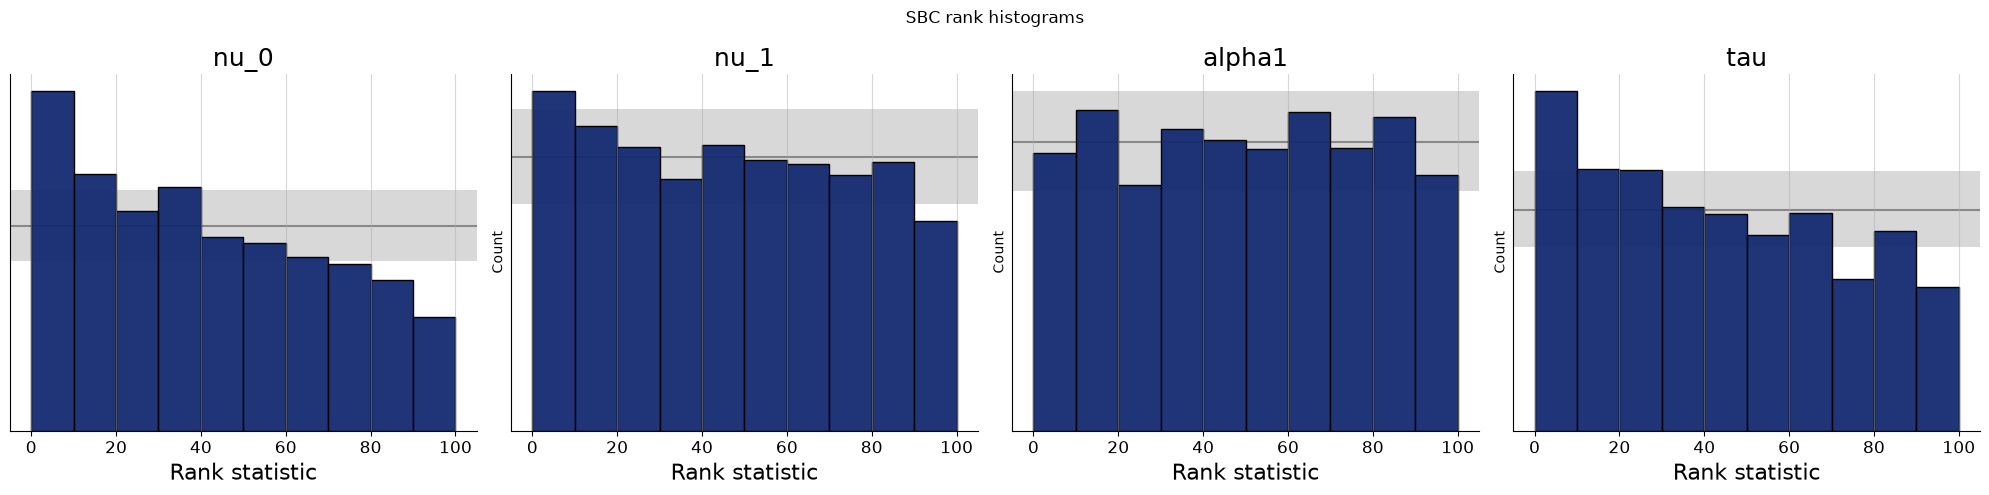

In [9]:
import matplotlib.pyplot as plt
f_sbc_hist = bf.diagnostics.plots.calibration_histogram(
    estimates=posterior_draws_sbc,
    targets=test_data_sbc,
    variable_keys=["nu", "alpha1", "tau"],
)
f_sbc_hist.suptitle("SBC rank histograms")
f_sbc_hist.tight_layout()
plt.show()

ECDF-difference version of the same check — more sensitive, and doesn't require choosing a bin count. The empirical curve should stay inside the shaded confidence band if calibration is good. Prefer this one over the histogram if the two disagree.

Also uses the **SBC batch**.

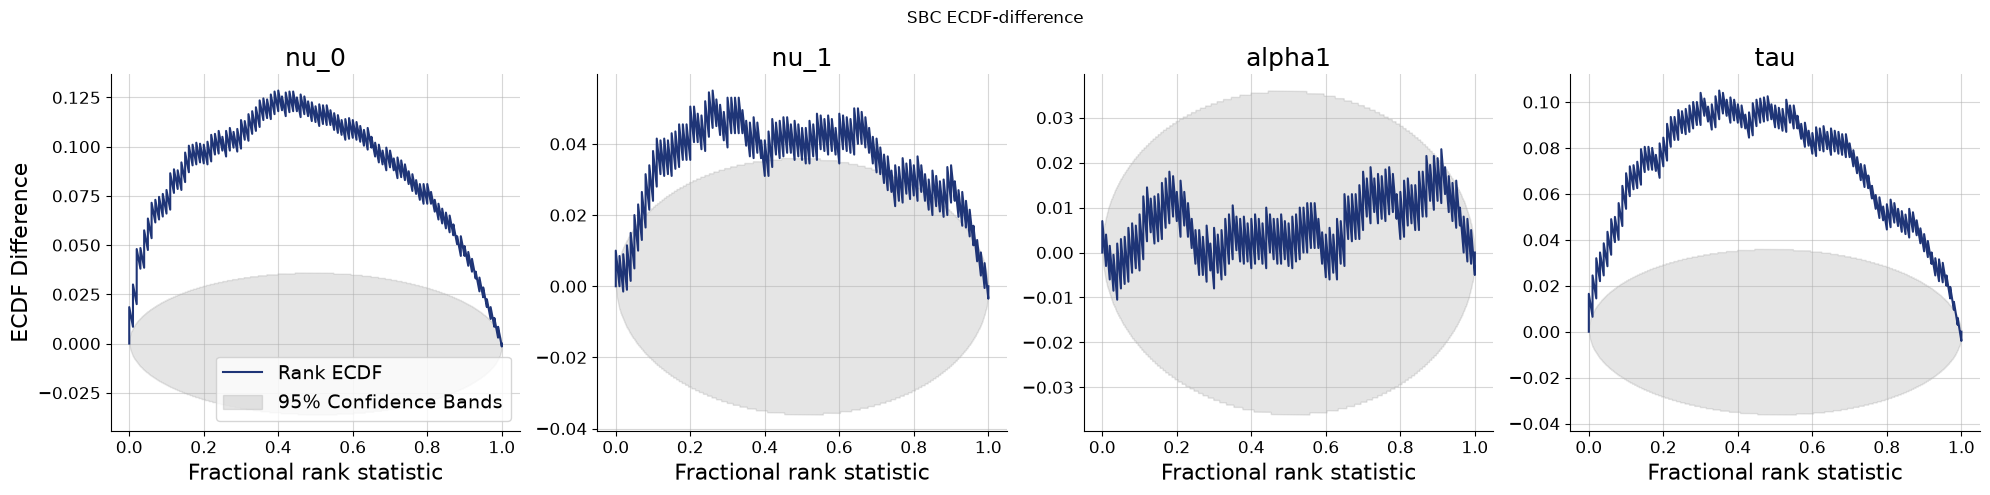

In [10]:
f_sbc_ecdf = bf.diagnostics.plots.calibration_ecdf(
    estimates=posterior_draws_sbc,
    targets=test_data_sbc,
    variable_keys=["nu", "alpha1", "tau"],
    difference=True,
)
f_sbc_ecdf.suptitle("SBC ECDF-difference")
f_sbc_ecdf.tight_layout()
plt.show()

7.3 Parameter recovery

Posterior point-estimate vs. the true simulated value, per parameter. Tight clustering around the y = x diagonal = good recovery. If one parameter scatters badly while the others look fine, that parameter is poorly identified by the data.

Uses the **recovery batch** (`test_data_rec` / `posterior_draws_rec`).

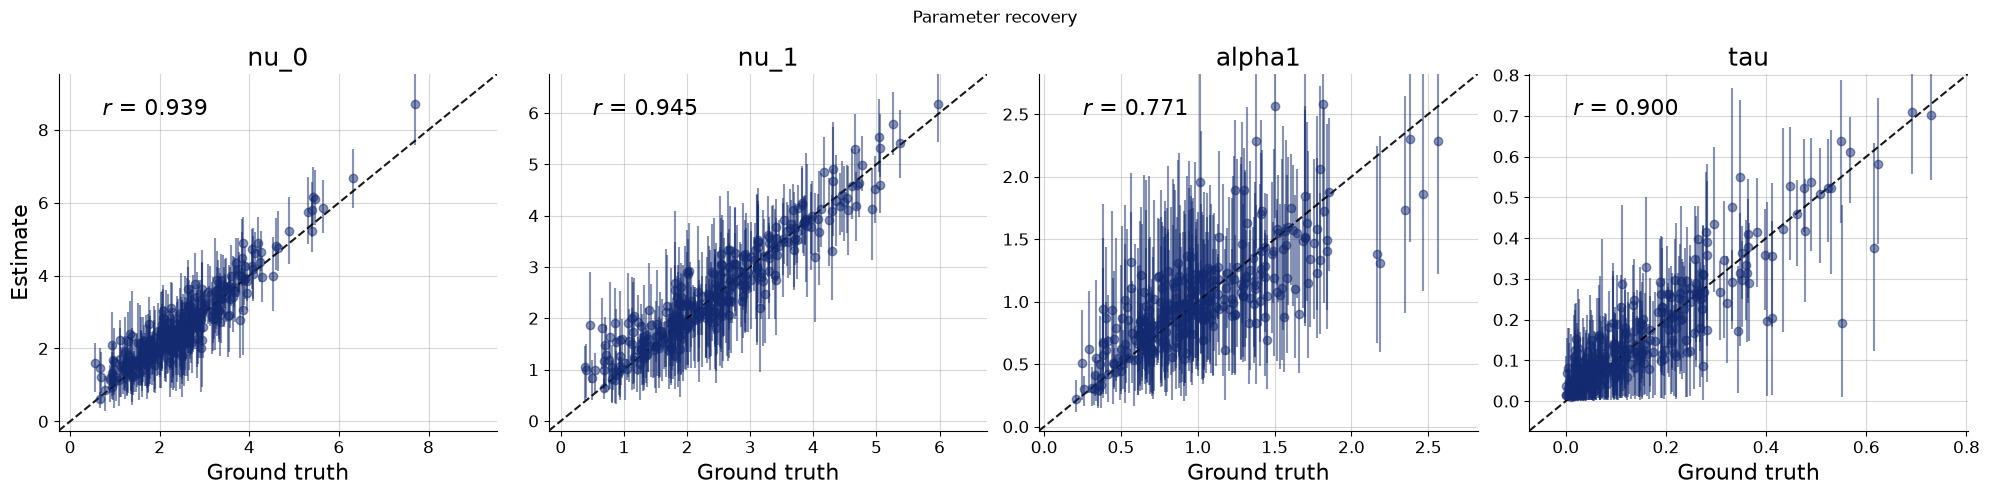

In [11]:
f_recovery = bf.diagnostics.plots.recovery(
    estimates=posterior_draws_rec,
    targets=test_data_rec,
    variable_keys=["nu", "alpha1", "tau"],
)
f_recovery.suptitle("Parameter recovery")
f_recovery.tight_layout()
plt.show()

7.4 Posterior z-score vs. contraction

Contraction = 1 - Var(posterior)/Var(prior): ~1 means the data pulled the posterior in tight relative to the prior (informative); ~0 means the posterior barely moved from the prior. Z-score = (posterior mean - true) / posterior SD: bias in SD units. Good behaviour = points clustered bottom-right (low |z|, high contraction). Middle-left = poorly identified parameter; upper/lower-left = prior-likelihood conflict; upper/lower-right = overfit to a wrong value.

Uses the **recovery batch**.

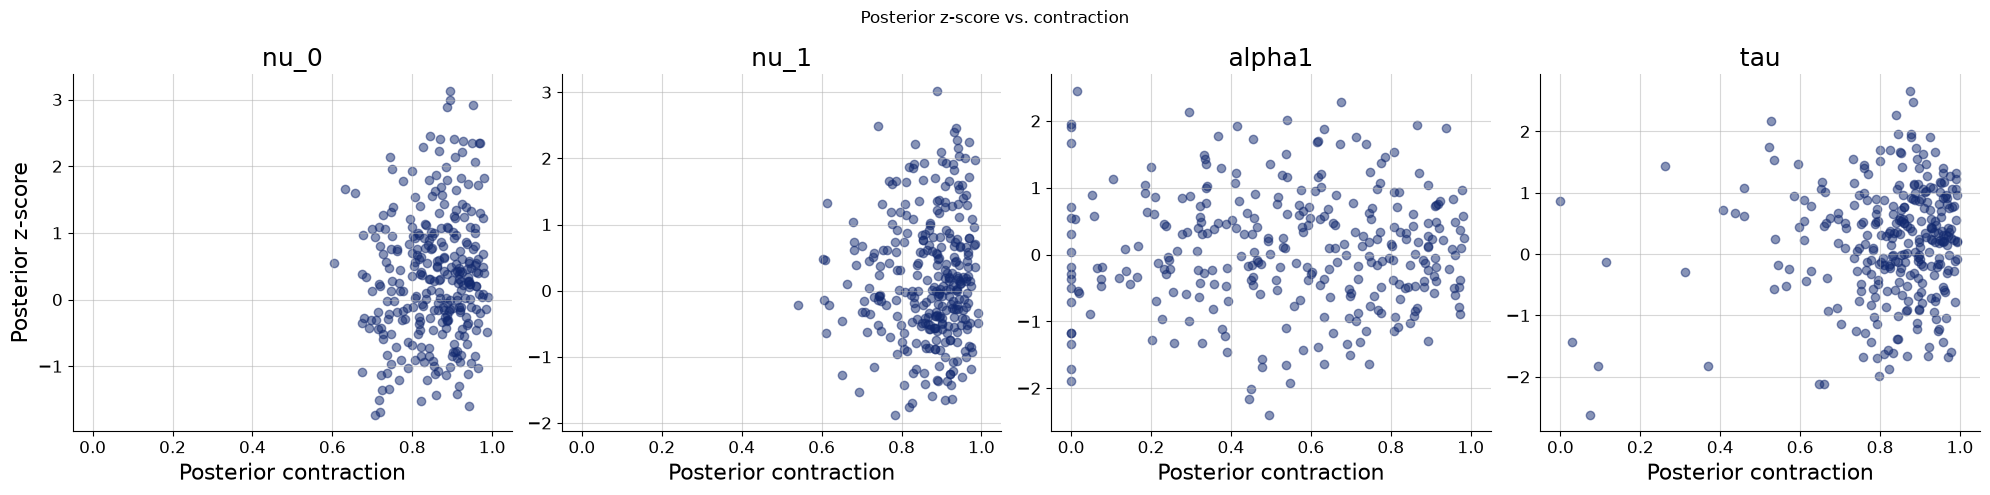

In [12]:
f_contraction = bf.diagnostics.plots.z_score_contraction(
    estimates=posterior_draws_rec,
    targets=test_data_rec,
    variable_keys=["nu", "alpha1", "tau"],
)
f_contraction.suptitle("Posterior z-score vs. contraction")
f_contraction.tight_layout()
plt.show()

## 8. Real Data Fitting (Evans et al. 2020) - TODO, diagnostics pair

In [13]:
import pandas as pd

df_rdm = pd.read_csv(
    "simulated_data.csv",
    usecols=["Sub", "list_id", "Correct", "Time1", "DoubleResp", "Time2"],
    dtype={
        "Sub" : "int32",
        "list_id": "int32",
        "Correct": "bool",
        "Time1": "float32",
        "DoubleResp": "bool",
        "Time2": "float32",
    },
    low_memory=False,
)

df_rdm.head()

,Sub,list_id,Correct,Time1,DoubleResp,Time2
0,1,1,True,0.3872,False,NaN
1,1,1,True,0.5844,False,NaN
2,1,1,True,0.4315,False,NaN
3,1,1,True,0.2795,False,NaN
4,1,1,True,0.5631,False,NaN


In [14]:
df_rdm = df_rdm.rename(
    columns={
        "Time1": "first_response_time",
        "Correct": "correct",
        "DoubleResp": "double_flag",
        "Time2": "second_response_time",
    }
)

df_rdm.head()

,Sub,list_id,correct,first_response_time,double_flag,second_response_time
0,1,1,True,0.3872,False,NaN
1,1,1,True,0.5844,False,NaN
2,1,1,True,0.4315,False,NaN
3,1,1,True,0.2795,False,NaN
4,1,1,True,0.5631,False,NaN


In [15]:
df_small_rdm = (
    df_rdm
    .groupby("Sub", group_keys=False)
    .sample(n=10000, replace=True, random_state=42)
    .reset_index(drop=True)
)

In [16]:
df_small_rdm.head(10)

,Sub,list_id,correct,first_response_time,double_flag,second_response_time
0,1,19,True,0.3347,False,NaN
1,1,3,True,0.4979,False,NaN
2,1,14,True,0.5128,False,NaN
3,1,13,True,0.4529,False,NaN
4,1,15,True,0.3602,False,NaN
5,1,16,True,0.2796,False,NaN
6,1,2,True,0.3988,False,NaN
7,1,12,False,0.3580,False,NaN
8,1,14,True,0.4042,False,NaN
9,1,21,True,0.2856,False,NaN


In [17]:
# Safely replace NaNs in Time2 with 0.0 and ensure float32 dtype
df_small_rdm.loc[:, "second_response_time"] = (
    df_small_rdm["second_response_time"]
    .fillna(0.0)
    .astype(np.float32)
)

# Verify no missing values remain
print("Remaining NaNs in second_response_time:", df_small_rdm["second_response_time"].isna().sum())

Remaining NaNs in second_response_time: 0


In [18]:
df_small_rdm.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Sub                   40000 non-null  int32  
 1   list_id               40000 non-null  int32  
 2   correct               40000 non-null  bool   
 3   first_response_time   40000 non-null  float32
 4   double_flag           40000 non-null  bool   
 5   second_response_time  40000 non-null  float32
dtypes: bool(2), float32(2), int32(2)
memory usage: 703.3 KB


In [19]:
df_small_rdm["Sub"].value_counts()

Sub
1    10000
2    10000
3    10000
4    10000
Name: count, dtype: int64

In [20]:
max_n   = 10000
grouped = df_small_rdm.groupby("Sub", sort=False)
n_lists = len(grouped)

conditions = {
    # summary_variables: each is shape (n_lists, max_n, 1), dtype float32
    "correct": np.stack(
        [g["correct"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),
    "first_response_time": np.stack(
        [g["first_response_time"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),
    "double_flag": np.stack(
        [g["double_flag"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),
    "second_response_time": np.stack(
        [g["second_response_time"].values.reshape(max_n, 1).astype(np.float32)
         for _, g in grouped],
        axis=0
    ),

    # inference_conditions: number of trials per list (shape (n_lists,)), dtype int32
    "n": np.array([g.shape[0] for _, g in grouped], dtype=np.int32)
}

print({k: v.shape for k, v in conditions.items()})
# => {
#   'correct':    (n_lists, 1000, 1),
#   'first_response_time':      (n_lists, 1000, 1),
#   'double_flag': (n_lists, 1000, 1),
#   'second_response_time':      (n_lists, 1000, 1),
#   'n':          (n_lists,)
# }


{'correct': (4, 10000, 1), 'first_response_time': (4, 10000, 1), 'double_flag': (4, 10000, 1), 'second_response_time': (4, 10000, 1), 'n': (4,)}


In [21]:
# Draw 1 000 posterior samples for your real‐data conditions using the trained Variation 2 workflow
posterior_real = approximator.sample(
    num_samples = 10000,
    conditions  = conditions
)


Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.12s/batch]


In [22]:
for name, arr in posterior_real.items():
    total = arr.size
    n_nan = np.isnan(arr).sum()
    pct   = 100 * n_nan / total
    print(f"{name:10s} → {n_nan}/{total} NaNs ({pct:.1f}%)")

nu         → 0/80000 NaNs (0.0%)
alpha1     → 0/40000 NaNs (0.0%)
tau        → 0/40000 NaNs (0.0%)


In [23]:
# 1) Get an ordered list of your subject IDs
group_keys     = list(grouped.groups.keys())

# 2) Pick the “first” one (or any by index)
first_list_id  = group_keys[0]
print("First list_id:", first_list_id)

# 3) Grab its data
data_first = grouped.get_group(first_list_id).reset_index(drop=True)
print("Data for first participant shape:", data_first.shape)

# 4) Find its index in that list
idx = group_keys.index(first_list_id)

# 5) Slice out *all* 1 0000 posterior draws for that subject
#    posterior_real has keys: "nu", "alpha1", "alpha2", "tau"
posterior_first = {
    "nu":     posterior_real["nu"][    idx, :, :],   # → (10000, 2)
    "alpha1": posterior_real["alpha1"][idx, :, 0],   # → (10000,)
    "tau":    posterior_real["tau"][   idx, :, 0]    # → (10000,)
}

print("Posterior for first participant:")
for name, arr in posterior_first.items():
    print(f"  {name:7s} → {arr.shape}")



First list_id: 1
Data for first participant shape: (10000, 6)
Posterior for first participant:
  nu      → (10000, 2)
  alpha1  → (10000,)
  tau     → (10000,)



Processing subject: 1
Data shape: (10000, 6)
Posterior shapes:
nu      → (10000, 2)
alpha1  → (10000,)
tau     → (10000,)

Processing subject: 2
Data shape: (10000, 6)
Posterior shapes:
nu      → (10000, 2)
alpha1  → (10000,)
tau     → (10000,)

Processing subject: 3
Data shape: (10000, 6)
Posterior shapes:
nu      → (10000, 2)
alpha1  → (10000,)
tau     → (10000,)

Processing subject: 4
Data shape: (10000, 6)
Posterior shapes:
nu      → (10000, 2)
alpha1  → (10000,)
tau     → (10000,)


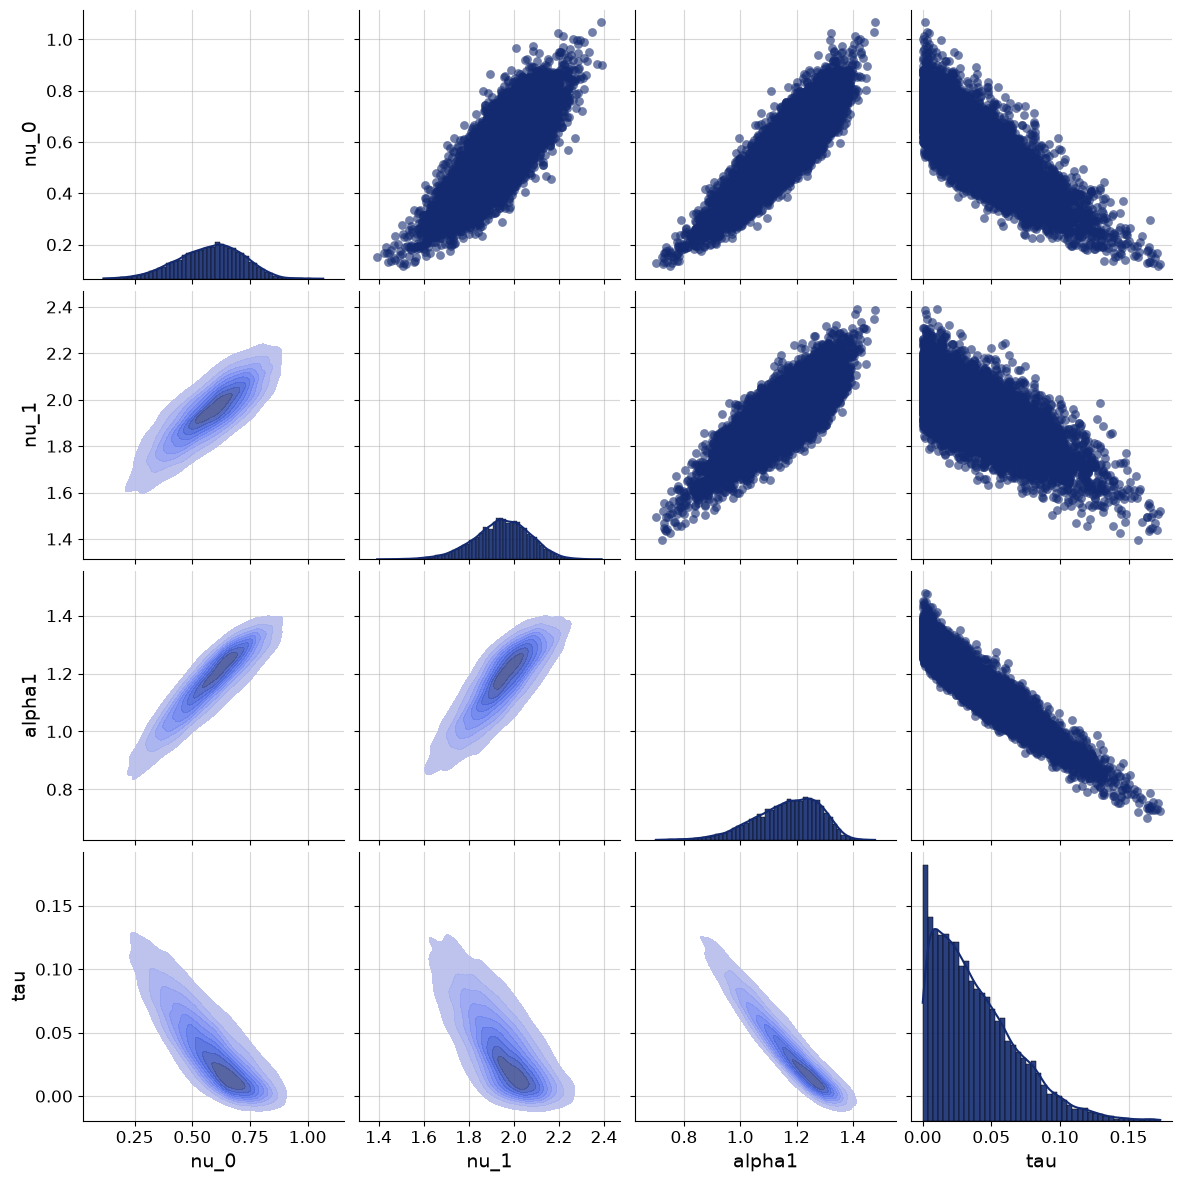

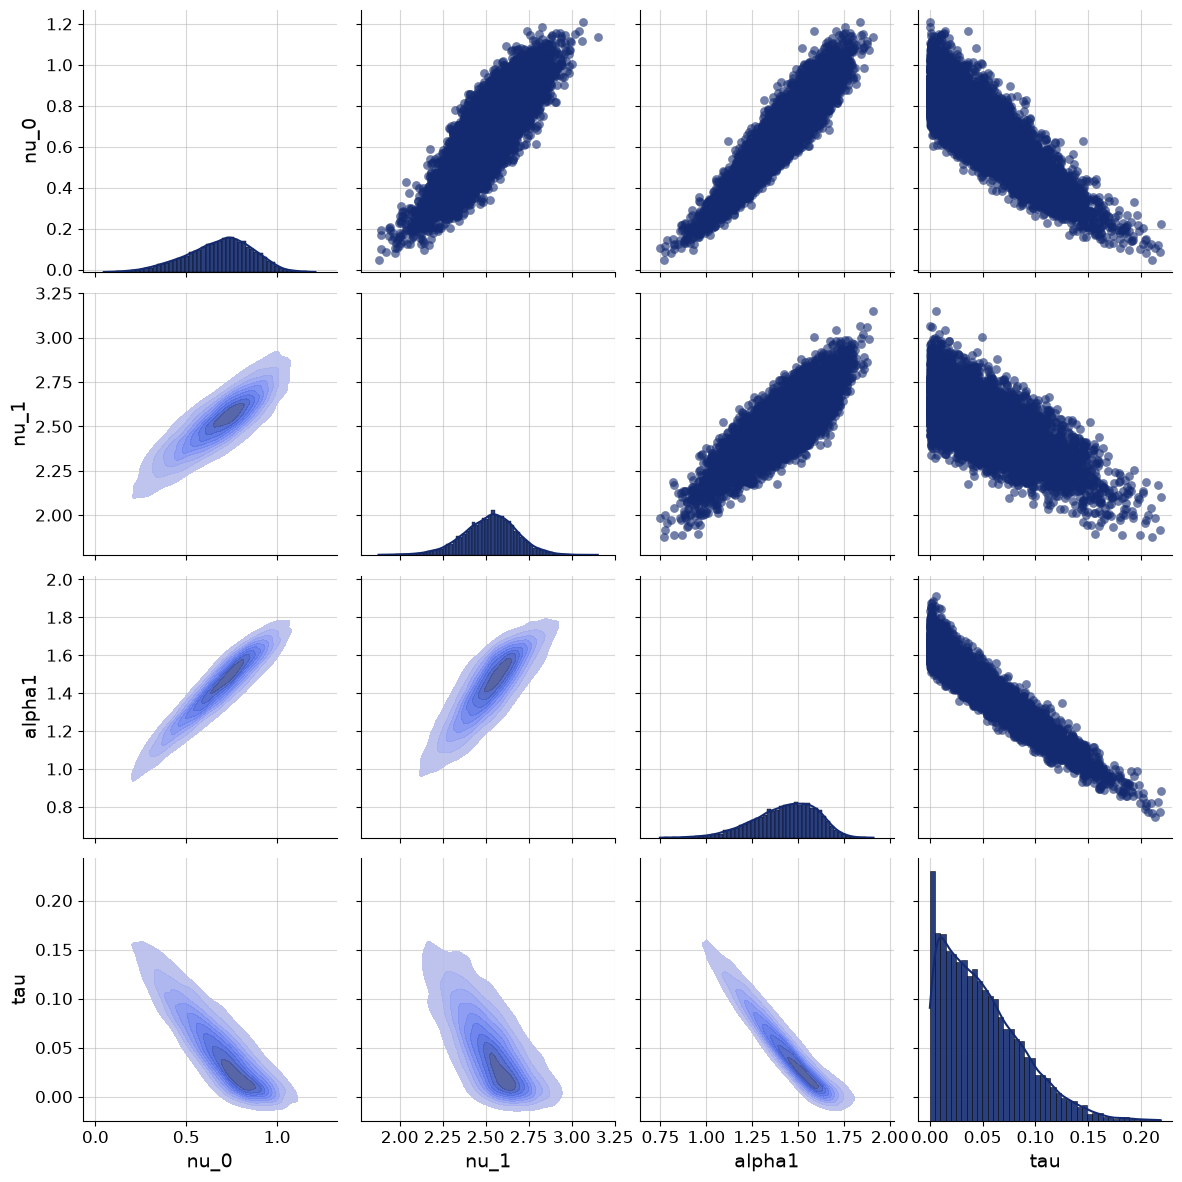

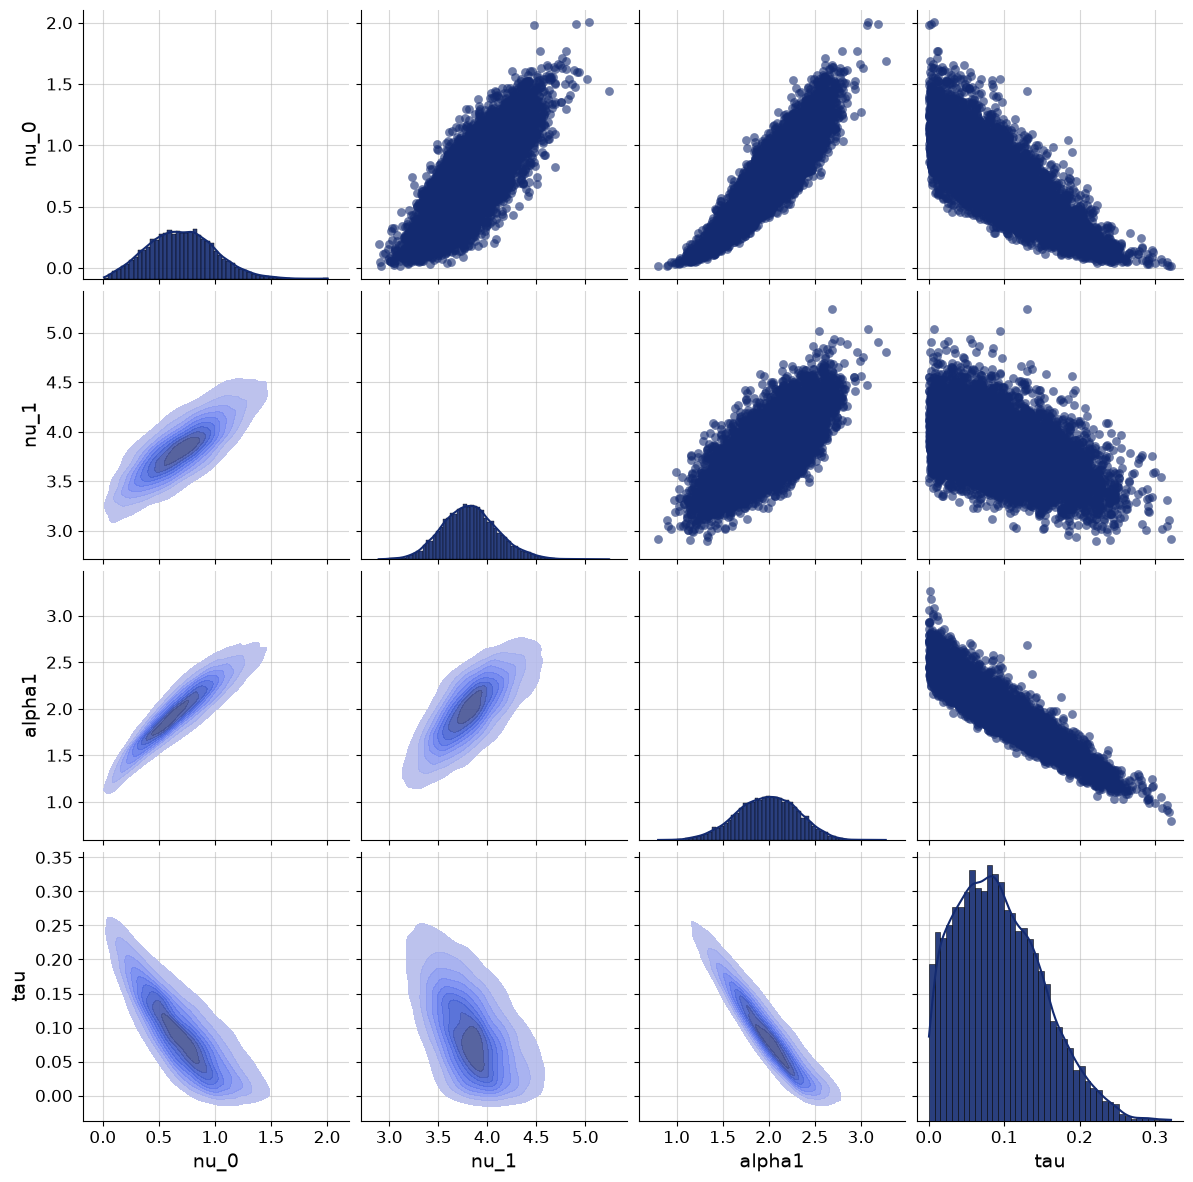

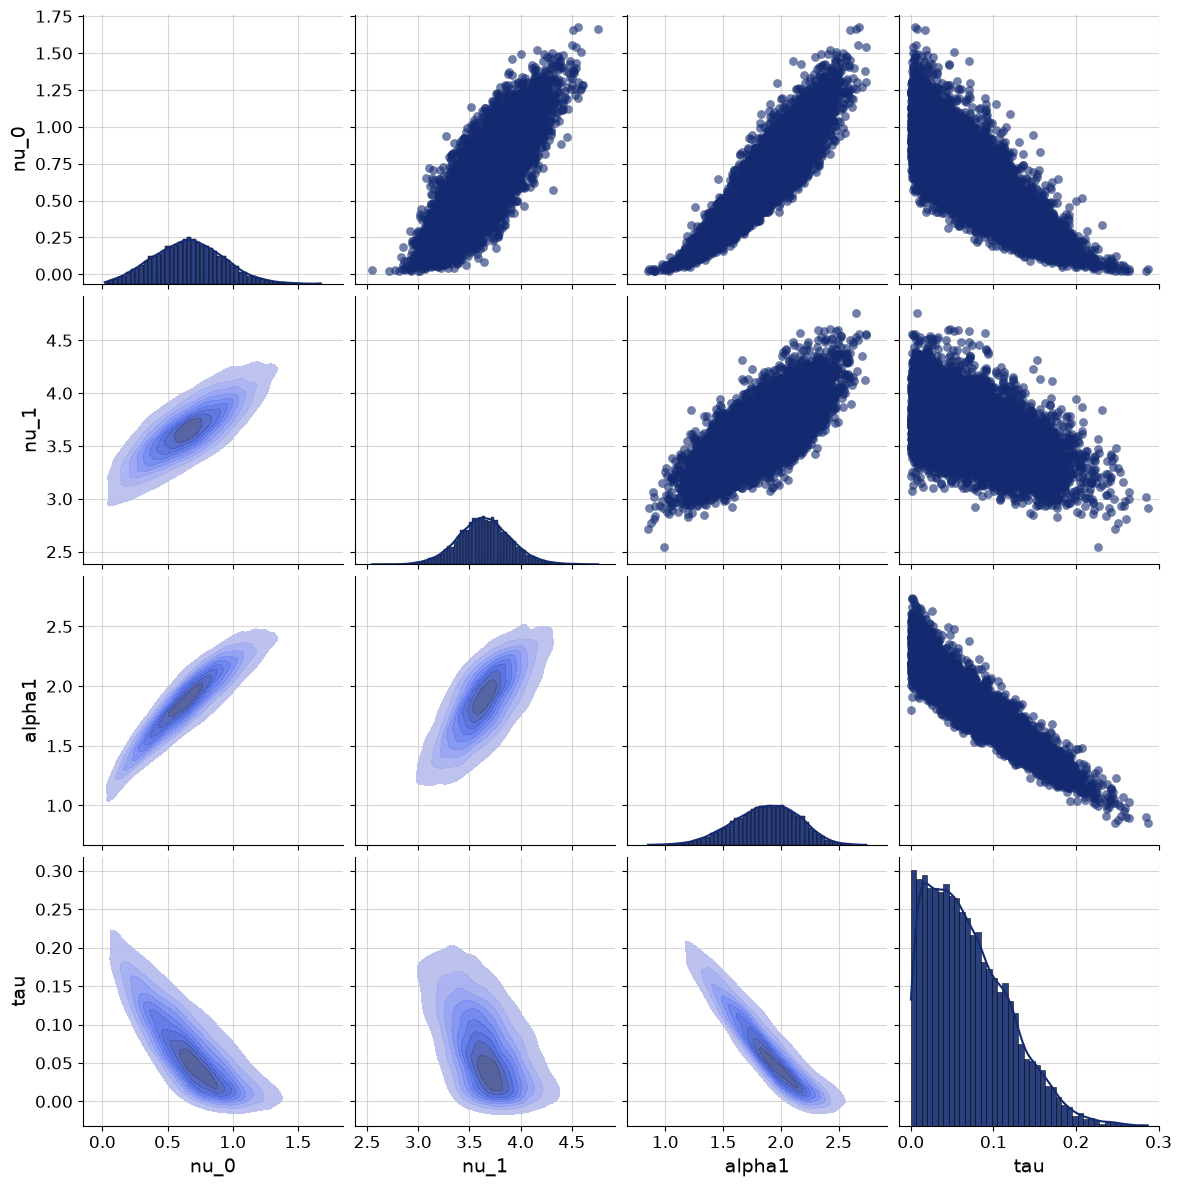

In [24]:
# Get an ordered list of your subject IDs
group_keys = list(grouped.groups.keys())

# Loop through all subjects
for subject_id in group_keys:
    print("\nProcessing subject:", subject_id)

    # Grab subject's data
    data_subject = grouped.get_group(subject_id).reset_index(drop=True)
    print("Data shape:", data_subject.shape)

    # Find index of subject
    idx = group_keys.index(subject_id)

    # Slice out all 10000 posterior draws for that subject
    posterior_subject = {
        "nu":     posterior_real["nu"][idx, :, :],      # (10000, 2)
        "alpha1": posterior_real["alpha1"][idx, :, 0],  # (10000,)
        "tau":    posterior_real["tau"][idx, :, 0]      # (10000,)
    }

    # Print posterior shapes
    print("Posterior shapes:")
    for name, arr in posterior_subject.items():
        print(f"{name:7s} → {arr.shape}")

    # Optional: Uncomment to plot (could be slow for many subjects)
    bf.diagnostics.pairs_posterior(estimates=posterior_subject)


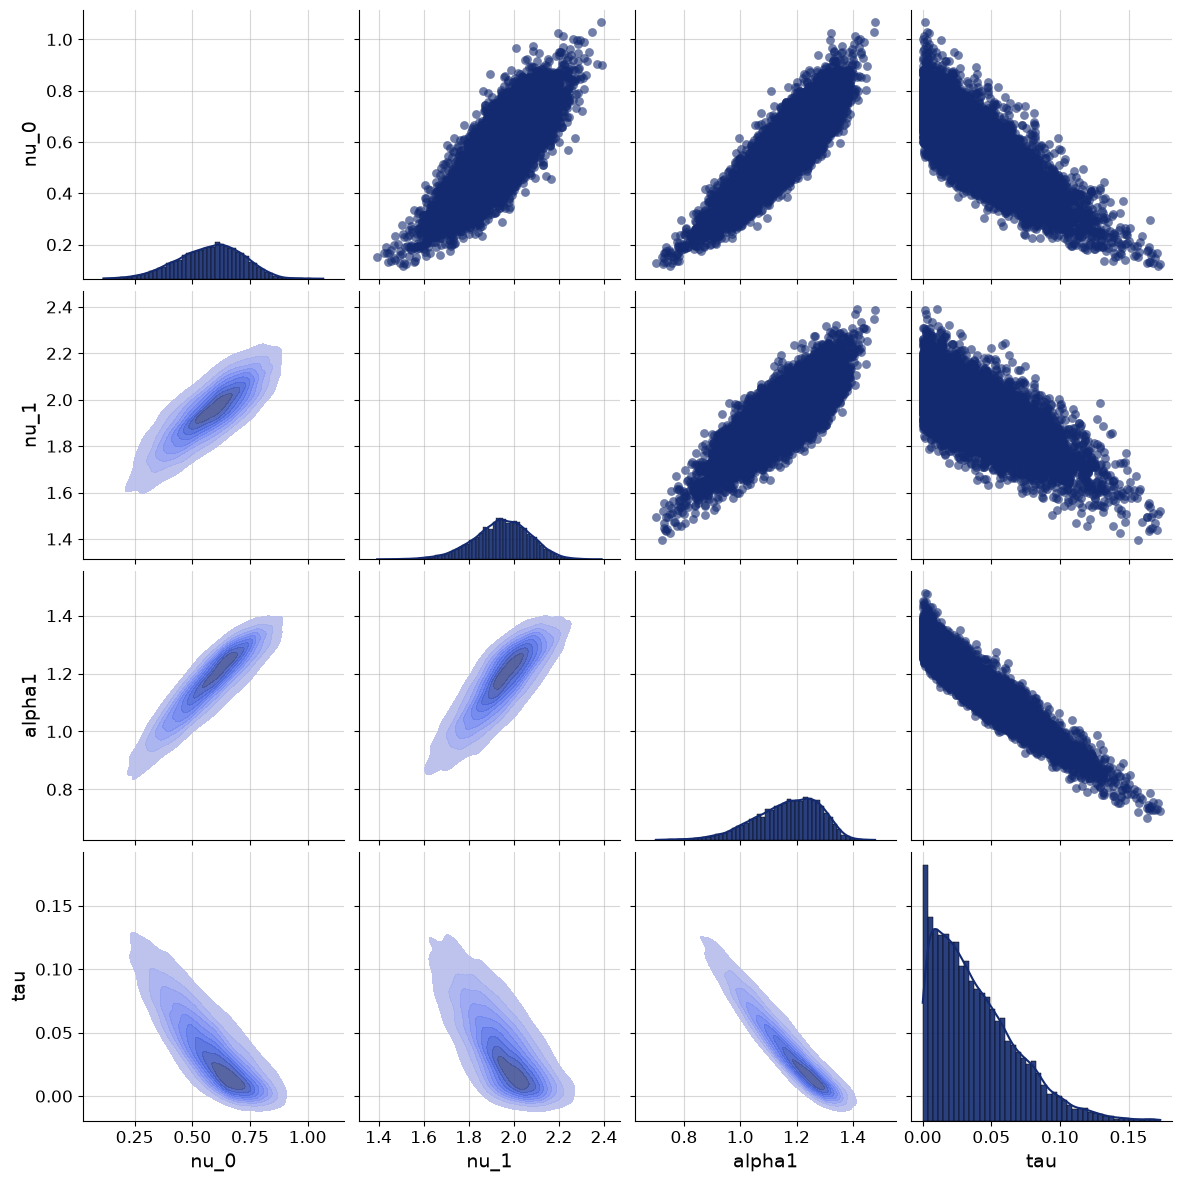

In [25]:
f=bf.diagnostics.pairs_posterior(estimates=posterior_first)

In [26]:
import matplotlib.pyplot as plt

# ECDF on a fixed grid
def ecdf_grid(first_response_time, correct, t_grid):
    """
    Compute weighted ECDFs for incorrect (c=0) and correct (c=1) trials.
    Returns an array of shape (2, len(t_grid)) where each row is
      P(Time1 ≤ t and class==c) over the full sample size.
    """
    corr = correct.astype(bool)
    N    = len(first_response_time)
    ecdf = np.zeros((2, len(t_grid)))

    for c in (0, 1):
        mask = corr if c == 1 else ~corr
        for i, t in enumerate(t_grid):
            ecdf[c, i] = np.sum((first_response_time <= t) & mask) / N

    return ecdf

# Posterior‐predictive ECDF plot for one subject 
def plot_group_pp_ecdf(grp_df,
                       approximator,
                       likelihood_fn,
                       n_posterior=500,
                       t_max=3.0,
                       dt=0.02):
    """
    grp_df: DataFrame for one subject, must contain
      "Time1", "Correct", "DoubleResp", "Time2"
    workflow: trained BasicWorkflow (Variation 2)
    likelihood_fn: your two‐threshold likelihood, e.g. likelihood_v2
    """
    n_trials = grp_df.shape[0]

    # A) Build the single‐subject “conditions” dict
    cond = {
        "first_response_time":      grp_df["first_response_time"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "correct":    grp_df["correct"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "double_flag": grp_df["double_flag"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "second_response_time":      grp_df["second_response_time"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "n":          np.array([n_trials], dtype=np.int32)
    }

    # B) Draw posterior samples
    post = approximator.sample(conditions=cond, num_samples=n_posterior)
    nu_draws     = post["nu"].squeeze()      # (n_post, 2)
    alpha1_draws = post["alpha1"].squeeze()  # (n_post,)
    tau_draws    = post["tau"].squeeze()     # (n_post,)

    # C) Empirical ECDF on a grid
    t_grid = np.linspace(0, t_max, 101)
    e_ecdf = ecdf_grid(
        first_response_time   = grp_df["first_response_time"].values,
        correct = grp_df["correct"].values,
        t_grid  = t_grid
    )

    # D) Posterior‐predictive ECDFs
    pp_ecdfs = np.zeros((n_posterior, 2, len(t_grid)))
    for i in range(n_posterior):
        sim = likelihood_fn(
            n       = n_trials,
            nu      = nu_draws[i],
            alpha1  = float(alpha1_draws[i]),
            tau     = float(tau_draws[i]),
            max_t   = t_max,
            dt      = dt
        )
        pp_ecdfs[i] = ecdf_grid(
            first_response_time   = sim["first_response_time"],
            correct = sim["correct"],
            t_grid  = t_grid
        )

    # E) Compute 25/50/75% quantiles
    q_low, q_med, q_high = np.quantile(pp_ecdfs,
                                       [0.25, 0.5, 0.75],
                                       axis=0)

    # F) Plot
    fig, ax = plt.subplots(figsize=(5,4))
    for c, label, col in zip([0,1], ["Incorrect","Correct"], ["C0","C1"]):
        ax.plot(t_grid,     e_ecdf[c],
                color=col, lw=2, label=f"{label} (emp)")
        ax.plot(t_grid,     q_med[c],
                color=col, lw=1, ls="--",
                label=f"{label} (pred median)")
        ax.fill_between(
            t_grid,
            q_low[c],
            q_high[c],
            color=col, alpha=0.3,
            label=f"{label} (50% pred)"
        )

    ax.set_xlabel("First‐response RT (s)")
    ax.set_ylabel("Weighted ECDF")
    ax.legend(fontsize="small", ncol=2)
    ax.set_title(f"Subject {grp_df['Sub'].iloc[0]} – Posterior‐Predictive ECDF")
    plt.tight_layout()
    return fig


Sampling: 100%|██████████| 1/1 [00:00<00:00, 33.62batch/s]


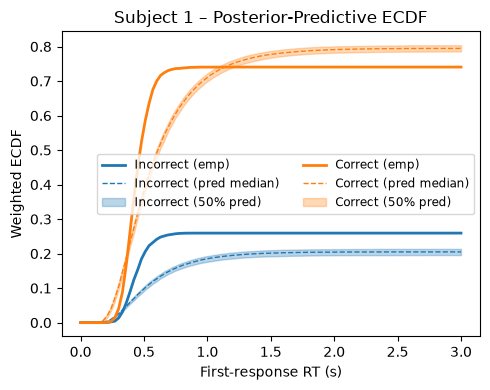

In [27]:
# for example, to plot for your first subject:
first_id = group_keys[0]
grp_df   = grouped.get_group(first_id).reset_index(drop=True)

fig = plot_group_pp_ecdf(
    grp_df,
    approximator,       # your trained Variation 2 workflow
    simulate_dataset,     # the two‐threshold simulator fn
    n_posterior=500,   # fewer draws if you want speed
    t_max=3.0,
    dt=0.02
)
plt.show()


Sampling: 100%|██████████| 1/1 [00:00<00:00, 32.02batch/s]


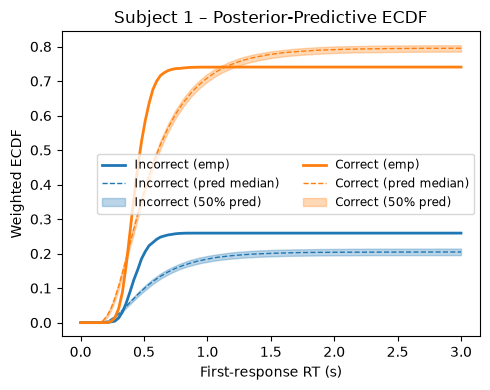

Sampling: 100%|██████████| 1/1 [00:00<00:00, 39.07batch/s]


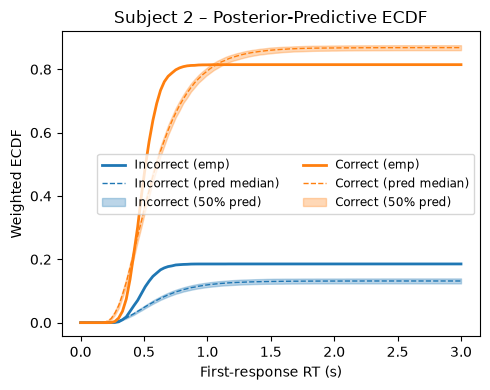

Sampling: 100%|██████████| 1/1 [00:00<00:00, 40.78batch/s]


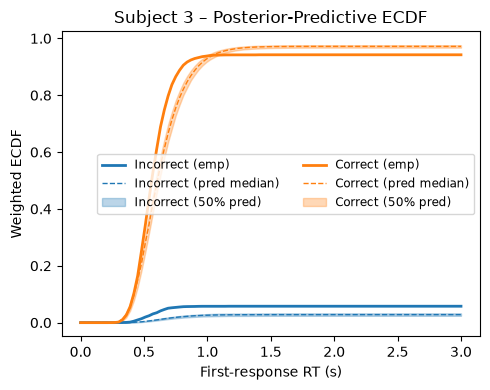

Sampling: 100%|██████████| 1/1 [00:00<00:00, 38.55batch/s]


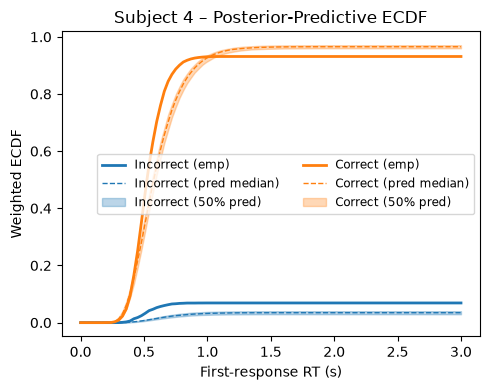

In [28]:
# Loop over all subjects and plot each ECDF
for list_id in group_keys:
    grp_df = grouped.get_group(list_id).reset_index(drop=True)
    fig = plot_group_pp_ecdf(
        grp_df,
        approximator,    # your trained Variation 2 workflow
        simulate_dataset,  # your two-threshold likelihood function
        n_posterior=500,
        t_max=3.0,
        dt=0.02
    )
    plt.show()  # display each figure before moving on



DOUBLE RESPONSE ANALYSIS


Sampling: 100%|██████████| 1/1 [00:00<00:00, 32.45batch/s]


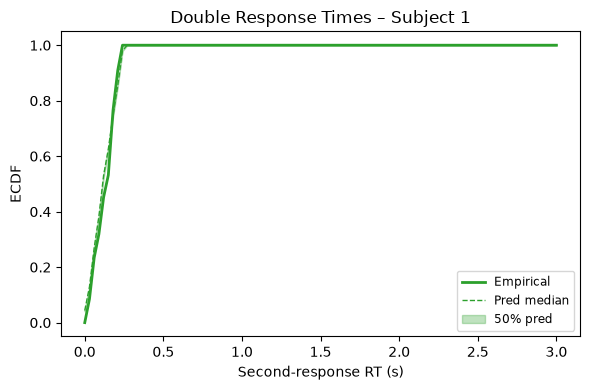

Sampling: 100%|██████████| 1/1 [00:00<00:00, 41.15batch/s]


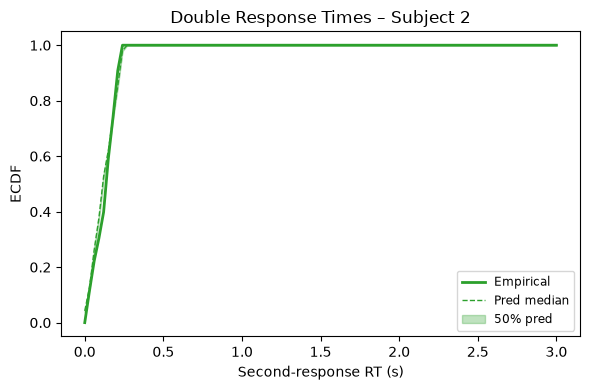

Sampling: 100%|██████████| 1/1 [00:00<00:00, 40.90batch/s]


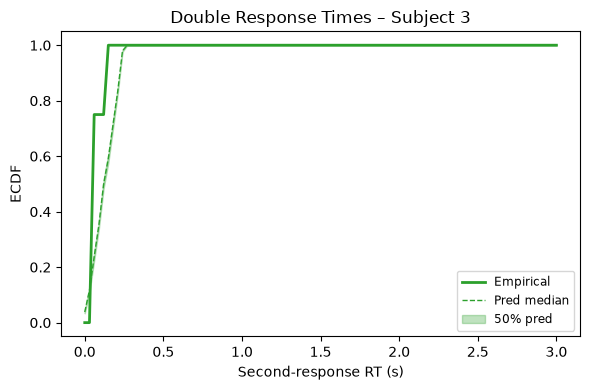

Sampling: 100%|██████████| 1/1 [00:00<00:00, 40.29batch/s]


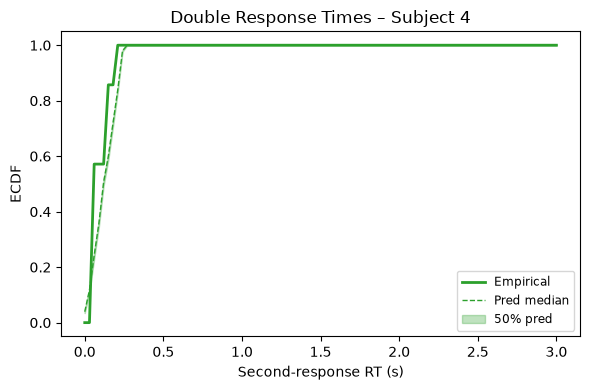

In [29]:
import matplotlib.pyplot as plt

def ecdf_grid_double_response(second_response_time, double_flag, t_grid):
    """
    ECDF of second‐response times only over trials where DoubleResp==True.
    Returns P(second_response_time <= t | DoubleResp=True) on the t_grid.
    """
    mask     = double_flag.astype(bool)
    n_double = mask.sum()
    if n_double == 0:
        return np.zeros_like(t_grid)
    ecdf = np.zeros(len(t_grid))
    for i, t in enumerate(t_grid):
        ecdf[i] = np.sum(second_response_time[mask] <= t) / n_double
    return ecdf

print("\n" + "="*50)
print("DOUBLE RESPONSE ANALYSIS")
print("="*50)

# iterate over each subject
for subject_id, grp_df in df_small_rdm.groupby("Sub", sort=False):
    n_trials = grp_df.shape[0]

    # build conditions dict with correct shapes/dtypes
    cond = {
        "first_response_time":      grp_df["first_response_time"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "correct":    grp_df["correct"].astype(bool).to_numpy().reshape(1, -1, 1).astype(np.float32),
        "double_flag": grp_df["double_flag"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "second_response_time":      grp_df["second_response_time"].to_numpy().reshape(1, -1, 1).astype(np.float32),
        "n":          np.array([n_trials], dtype=np.int32)
    }

    # draw posterior samples under Variation 2 workflow
    post = approximator.sample(conditions=cond, num_samples=500)
    nu_draws     = post["nu"].squeeze()      # (500, 2)
    alpha1_draws = post["alpha1"].squeeze()  # (500,)
    tau_draws    = post["tau"].squeeze()     # (500,)

    # empirical ECDF for Time2
    t_grid_double = np.linspace(0, 3.0, 101)
    e_ecdf_double = ecdf_grid_double_response(
        second_response_time      = grp_df["second_response_time"].values,
        double_flag = grp_df["double_flag"].values,
        t_grid     = t_grid_double
    )

    # posterior‐predictive ECDFs for Time2
    pp_ecdfs_double = np.zeros((500, len(t_grid_double)))
    for i in range(500):
        sim = simulate_dataset(
            n       = n_trials,
            nu      = nu_draws[i],
            alpha1  = float(alpha1_draws[i]),
            tau     = float(tau_draws[i])
        )
        pp_ecdfs_double[i] = ecdf_grid_double_response(
            second_response_time     = sim["second_response_time"],
            double_flag = sim["double_flag"],
            t_grid     = t_grid_double
        )

    # compute 25/50/75% quantiles
    q_low, q_med, q_high = np.quantile(pp_ecdfs_double,
                                       [0.25, 0.5, 0.75],
                                       axis=0)

    # plot
    plt.figure(figsize=(6, 4))
    plt.plot(t_grid_double, e_ecdf_double,
             color="C2", lw=2, label="Empirical")
    plt.plot(t_grid_double, q_med,
             color="C2", lw=1, ls="--", label="Pred median")
    plt.fill_between(t_grid_double, q_low, q_high,
                     color="C2", alpha=0.3, label="50% pred")
    plt.xlabel("Second‐response RT (s)")
    plt.ylabel("ECDF")
    plt.title(f"Double Response Times – Subject {subject_id}")
    plt.legend(fontsize="small")
    plt.tight_layout()
    plt.show()



In [30]:
 # ─── A) Simulate test data with known parameters ─────────────────────────
# Draw 1 0000 “test” datasets from your two-threshold simulator
test_sims_v2 = simulator.sample(200)

Sampling: 100%|██████████| 1/1 [00:00<00:00,  1.34batch/s]


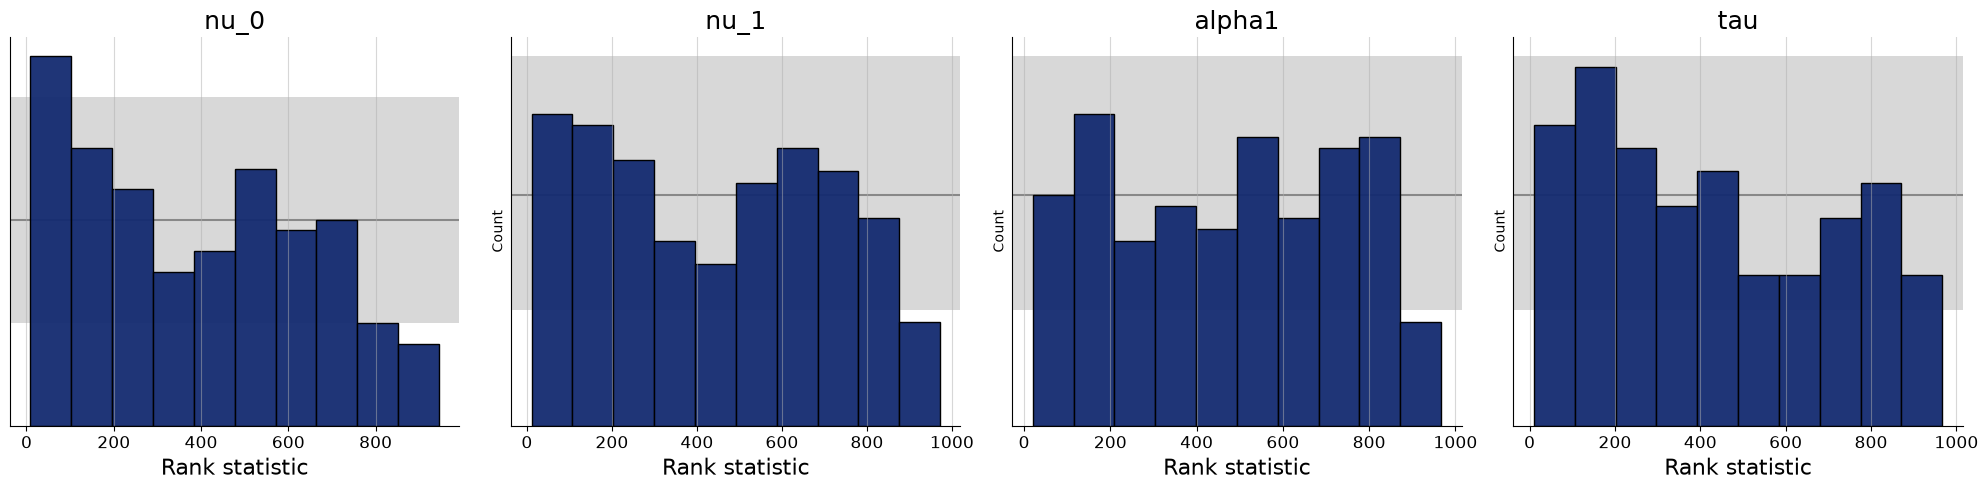

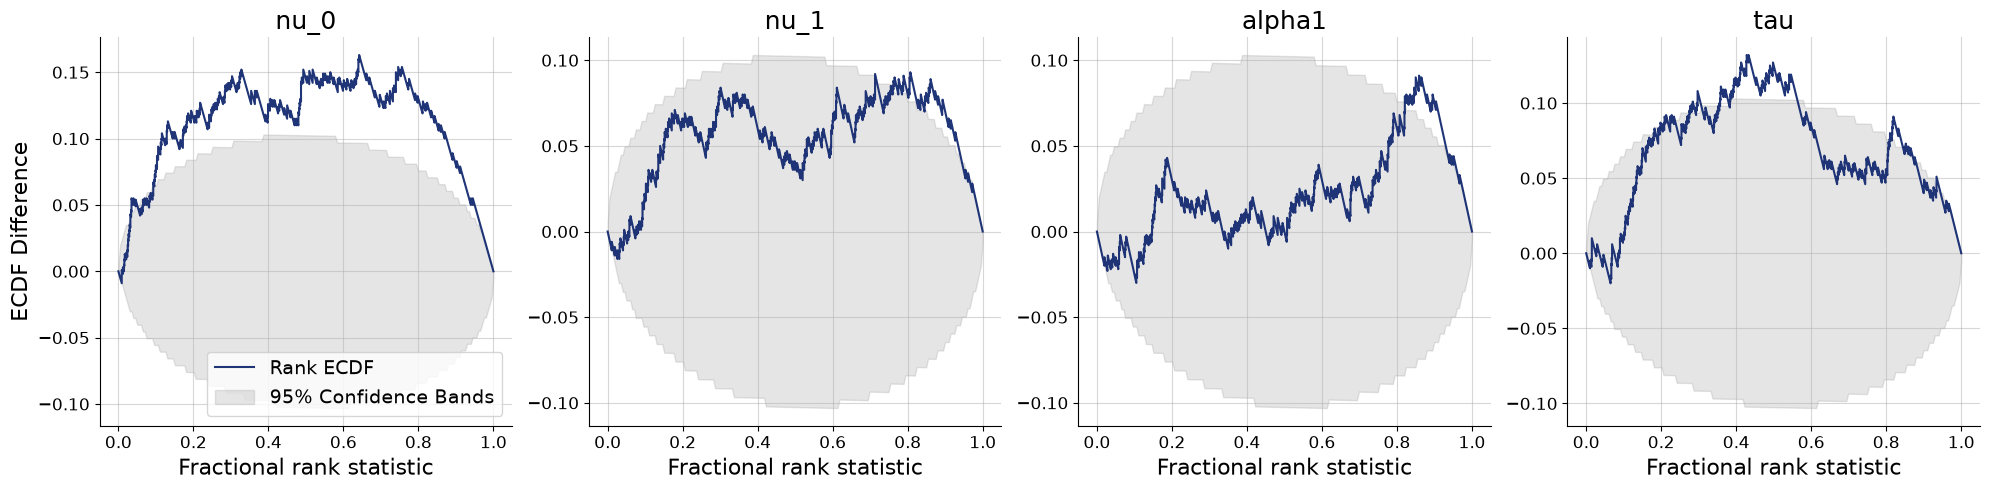

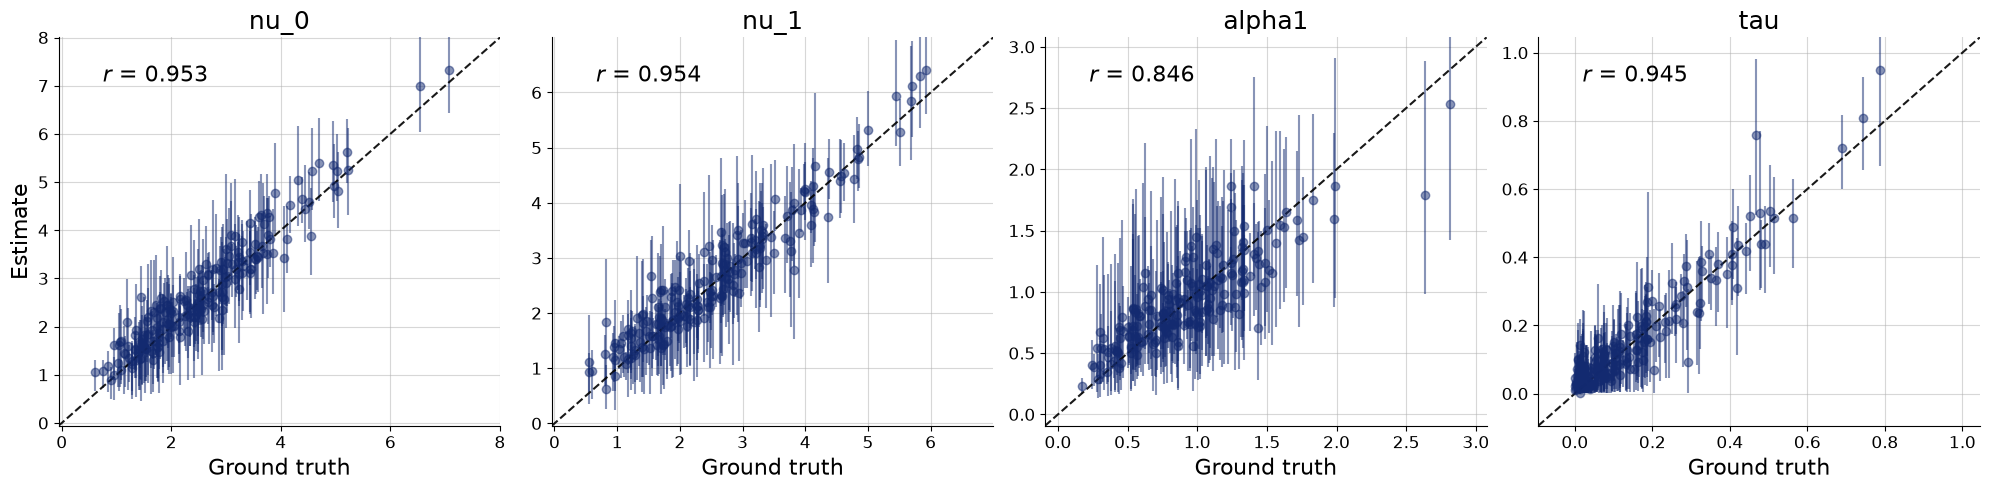

In [31]:

# ─── B) Draw posteriors on that test data ───────────────────────────────
posterior_sims_v2 = approximator.sample(
    num_samples = 1000,
    conditions  = test_sims_v2
)

# ─── C) Calibration histogram for each parameter ────────────────────────
f_hist_v2 = bf.diagnostics.plots.calibration_histogram(
    estimates = posterior_sims_v2,
    targets   = test_sims_v2
)

# ─── D) Calibration ECDF-difference plot ────────────────────────────────
f_ecdf_v2 = bf.diagnostics.plots.calibration_ecdf(
    estimates  = posterior_sims_v2,
    targets    = test_sims_v2,
    difference = True
)

# ─── E) Recovery scatterplots (true vs. inferred) ────────────────────────
f_recov_v2 = bf.diagnostics.plots.recovery(
    estimates = posterior_sims_v2,
    targets   = test_sims_v2
)

# Display the figures
for fig in (f_hist_v2, f_ecdf_v2, f_recov_v2):
    fig.show()
